# K-mouflage : comparaison sans / avec potentiel de quintessence

Modèle : power-law $K(X) = -1 + X + K_0 X^m$, couplage exponentiel $\beta$.

Potentiel : $V(\phi) = V_0 \, e^{-\lambda \phi / M_{\rm Pl}}$ (quintessence canonique).

Paramètres explorés : $V_0 = 0.7$, $\lambda \in \{0.5, 0.9, 1.2\}$.

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from kmouflage.solver             import KMouflageBackground, CosmologicalParams
from kmouflage.models.k_functions import make_powerlaw_K
from kmouflage.models.couplings   import make_exponential_coupling
from kmouflage.models.potential   import make_exponential_potential
from kmouflage.calibrate_M4       import calibrate_M4_tilde
from kmouflage.verify             import verify

## Paramètres communs

In [23]:
K_MODEL  = make_powerlaw_K(K0=1, m=3)
COUPLING = make_exponential_coupling(beta=0.1)
COSMO    = CosmologicalParams(H0_input=67.36, Omega_m0=0.25)

SOLVER_KW = dict(model=K_MODEL, coupling=COUPLING, cosmo=COSMO)

V0  = 0.7
LAMS = [0, 1, 3, 10 ]  # bouton w_DE(z=0)

## Intégration

In [ ]:
TARGET_ODE = 0.75

# ── modèle nu (sans potentiel) ───────────────────────────────────────────────
s_bare = KMouflageBackground(**SOLVER_KW)
s_bare.run(verbose=False)

# ── modèles avec potentiel : calibration M4_tilde pour chaque λ ─────────────
s_quints = []
M4_calibrated = []

for lam in LAMS:
    bg = KMouflageBackground(**SOLVER_KW, potential=make_exponential_potential(V0=V0, lam=lam))
    M4, Ode0, nit = calibrate_M4_tilde(bg, target_Omega_DE=TARGET_ODE, tol=1e-5, verbose=True, method ="brentq")
    s_quints.append(bg)
    M4_calibrated.append(M4)

# ── résumé ───────────────────────────────────────────────────────────────────
print(f"\n{'':─<60}")
print(f"Bare model     : w_DE(z=0) = {float(s_bare.w_de_def(0.0)):.4f}")
for lam, sq, m4 in zip(LAMS, s_quints, M4_calibrated):
    print(f"λ = {lam:<5}  M4_tilde = {m4:.6f}"
          f"  Ω_DE(0) = {float(sq.Omega_de_def(0.0)):.5f}"
          f"  w_DE(0) = {float(sq.w_de_def(0.0)):.4f}")

## Grille redshift commune

In [ ]:
z  = np.linspace(0, 10, 4000)
N  = np.log(1.0 / (1.0 + z))
N0 = 0.0

colors = ["C1", "C2", "C3","C4"]
labels = [f"avec potentiel λ={l}" for l in LAMS]

## 1 — Équation d'état $w_\phi(z)$

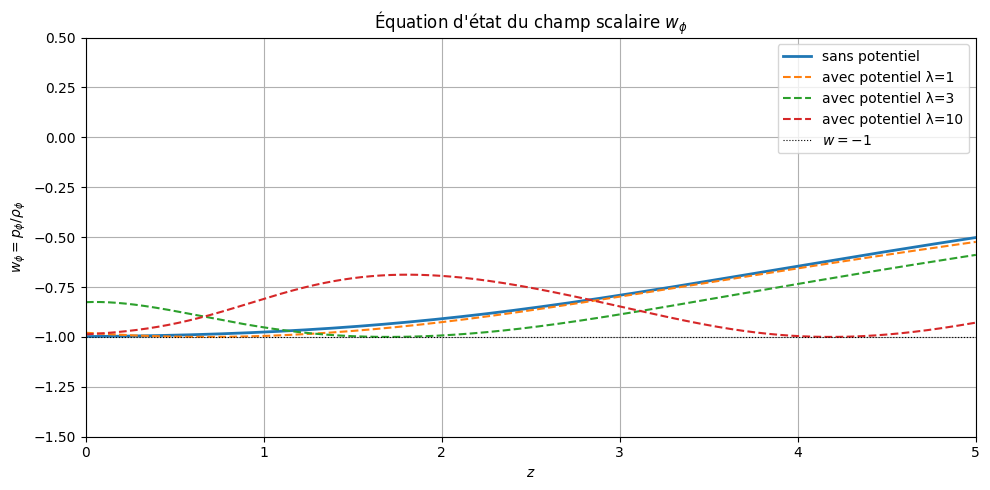

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, s_bare.w_phi(N), color="C0", lw=2, label="sans potentiel")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, sq.w_phi(N), color=c, ls="--", label=lb)

ax.axhline(-1, color="k", lw=0.8, ls=":", label=r"$w=-1$")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi = p_\phi / \rho_\phi$")
ax.set_title(r"Équation d'état du champ scalaire $w_\phi$")
ax.set_xlim(0, 5)
ax.set_ylim(-1.5, 0.5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 2 — Équation d'état de l'énergie noire $w_{\rm DE}(z)$

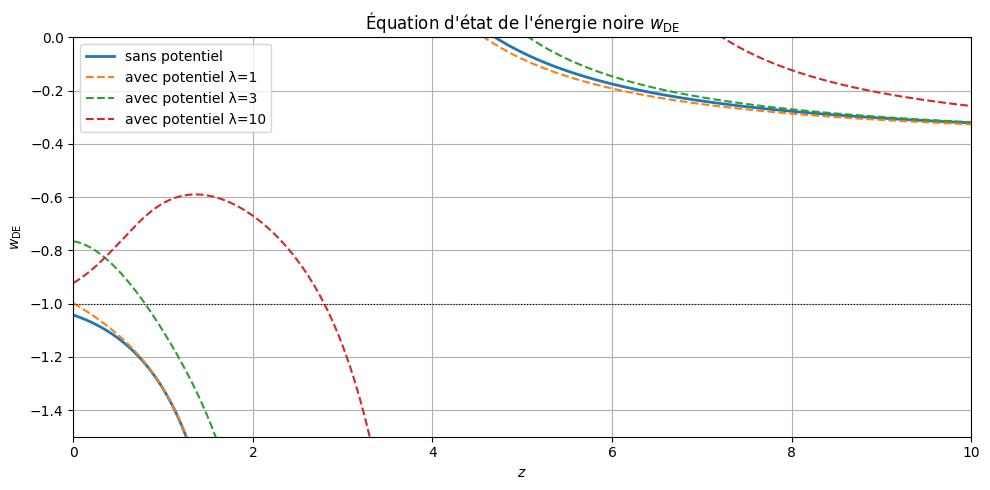

In [8]:
def safe_w(solver, N_grid):
    rho = solver.rho_de_def(N_grid)
    w   = solver.w_de_def(N_grid)
    sign = np.sign(rho)
    bad  = (sign != np.roll(sign, 1)) | (sign != np.roll(sign, -1))
    return np.where(bad, np.nan, w)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, safe_w(s_bare, N), color="C0", lw=2, label="sans potentiel")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, safe_w(sq, N), color=c, ls="--", label=lb)

ax.axhline(-1, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm DE}$")
ax.set_title(r"Équation d'état de l'énergie noire $w_{\rm DE}$")
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 0.0)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 3 — Paramètres de densité $\Omega_i(z)$

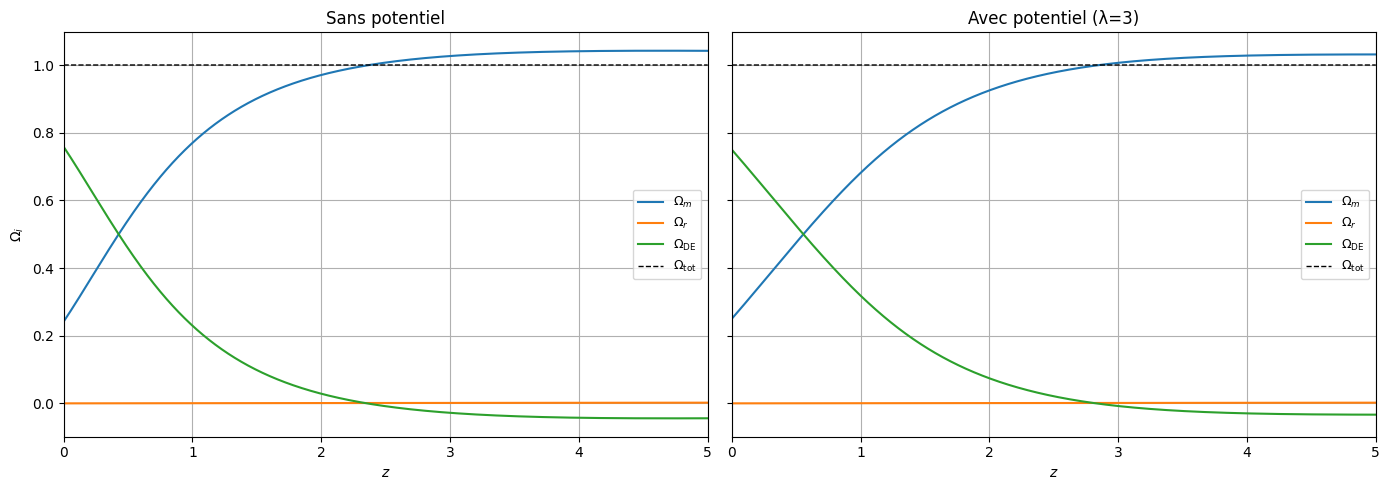

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

solvers = [s_bare, s_quints[1]]          # bare vs λ=0.9
titles  = ["Sans potentiel", f"Avec potentiel (λ={LAMS[1]})"]  

for ax, s, title in zip(axes, solvers, titles):
    ax.plot(z, s.Omega_m(N),      label=r"$\Omega_m$",   color="C0")
    ax.plot(z, s.Omega_r(N),      label=r"$\Omega_r$",   color="C1")
    ax.plot(z, s.Omega_de_def(N), label=r"$\Omega_{\rm DE}$", color="C2")
    tot = s.Omega_m(N) + s.Omega_r(N) + s.Omega_de_def(N)
    ax.plot(z, tot, "k--", lw=1, label=r"$\Omega_{\rm tot}$")
    ax.set_xlabel(r"$z$")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True)
    ax.set_xlim(0, 5)

axes[0].set_ylabel(r"$\Omega_i$")

plt.tight_layout()
plt.show()

## 4 — Écart de taux de Hubble $\Delta H / H_{\rm bare}$

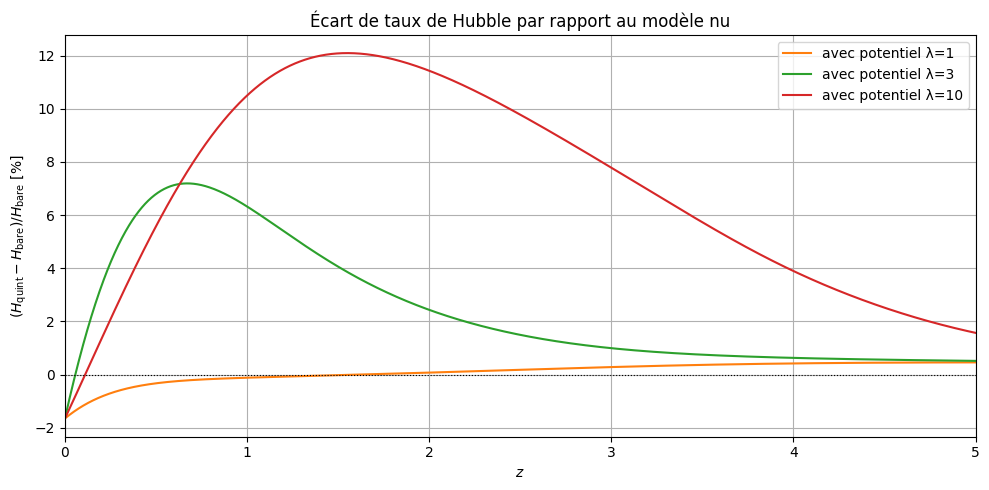

In [10]:
H0_km = COSMO.H0_input
H_bare = s_bare.E_conf(N) * (1.0 + z) * H0_km

fig, ax = plt.subplots(figsize=(10, 5))
for sq, c, lb in zip(s_quints, colors, labels):
    H_q = sq.E_conf(N) * (1.0 + z) * H0_km
    ax.plot(z, (H_q - H_bare) / H_bare * 100, color=c, label=lb)

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(H_{\rm quint} - H_{\rm bare})/H_{\rm bare}$ [%]")
ax.set_title("Écart de taux de Hubble par rapport au modèle nu")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 4b — Écart de taux de Hubble par rapport à $\Lambda$CDM

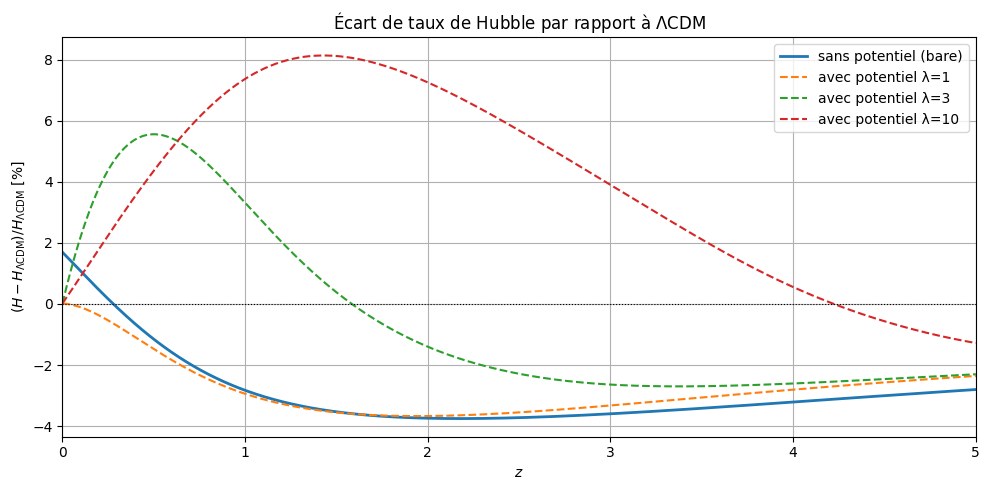

In [19]:
Omega_L0 = 1.0 - COSMO.Omega_m0 - COSMO.Omega_r0
H_lcdm = COSMO.H0_input * np.sqrt(
    COSMO.Omega_m0 * (1.0 + z)**3
    + COSMO.Omega_r0 * (1.0 + z)**4
    + Omega_L0
)

H0_km  = COSMO.H0_input
H_bare = s_bare.E_conf(N) * (1.0 + z) * H0_km

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, (H_bare - H_lcdm) / H_lcdm * 100,
        color="C0", lw=2, label="sans potentiel (bare)")
for sq, c, lb in zip(s_quints, colors, labels):
    H_q = sq.E_conf(N) * (1.0 + z) * H0_km
    ax.plot(z, (H_q - H_lcdm) / H_lcdm * 100, color=c, ls="--", label=lb)

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(H - H_{\Lambda\rm CDM})/H_{\Lambda\rm CDM}$ [%]")
ax.set_title(r"Écart de taux de Hubble par rapport à $\Lambda$CDM")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6 — Évolution du champ scalaire $\phi(z)$

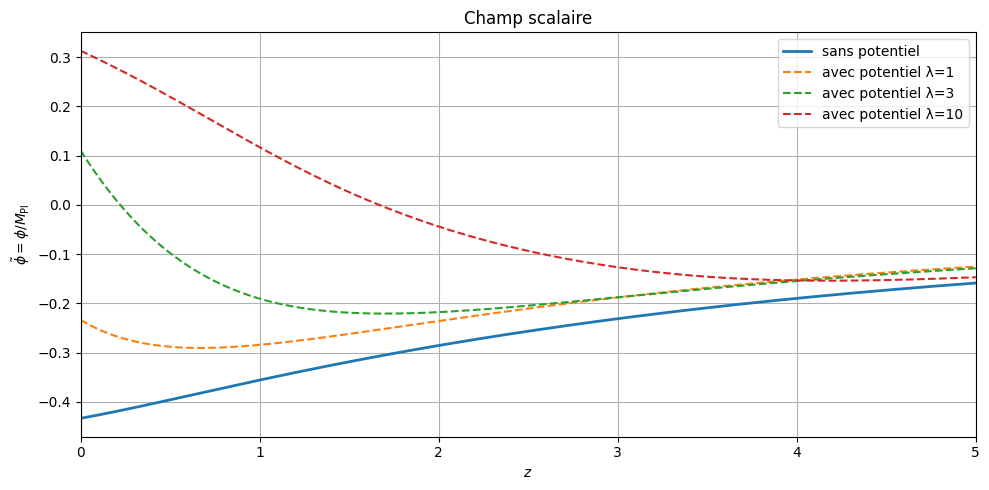

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, s_bare.phi(N), color="C0", lw=2, label="sans potentiel")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, sq.phi(N), color=c, ls="--", label=lb)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\tilde{\phi} = \phi / M_{\rm Pl}$")
ax.set_title("Champ scalaire")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7 — Potentiel de quintessence $V(\phi(z))$

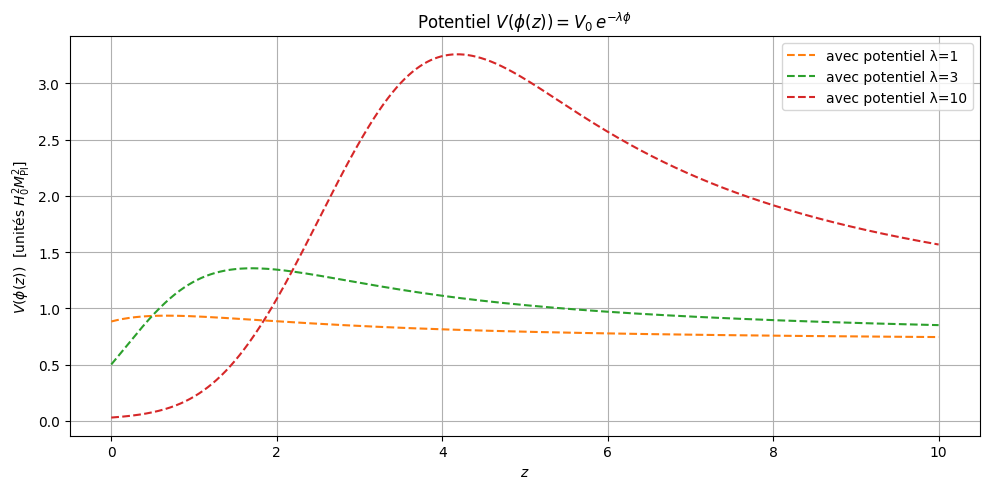

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

for sq, lam, c, lb in zip(s_quints, LAMS, colors, labels):
    V_z = V0 * np.exp(-lam * sq.phi(N))
    ax.plot(z, V_z, color=c, ls="--", label=lb)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$V(\phi(z))$  [unités $H_0^2 M_{\rm Pl}^2$]")
ax.set_title(r"Potentiel $V(\phi(z)) = V_0\,e^{-\lambda\phi}$")

ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8 — $f\sigma_8(z)$ : K-mouflage vs ΛCDM vs DESI DR1

In [ ]:
from kmouflage.growth import KmouflageGrowth, LCDMGrowth
from scipy.interpolate import interp1d

SIGMA8_0 = 0.811

DESI_POINTS = [
    ("PV",   0.070, 0.450, 0.055),
    ("BGS",  0.295, 0.417, 0.080),
    ("LRG1", 0.510, 0.439, 0.038),
    ("LRG2", 0.706, 0.460, 0.036),
    ("LRG3", 0.930, 0.439, 0.038),
    ("ELG2", 1.317, 0.482, 0.057),
    ("QSO",  1.491, 0.435, 0.100),
]
DESI_COLS = ["#7c3aed","#16a34a","#2563eb","#0891b2","#d97706","#dc2626","#9333ea"]

def add_fsigma8(r, sigma8_0=SIGMA8_0):
    r["fsigma8"] = r["f"] * sigma8_0 * r["Dp"]
    return r

# ── styles par modèle ────────────────────────────────────────────────────────
_names  = ["bare"] + [f"λ={l}" for l in LAMS]
_cols   = ["C0"]   + list(colors[:len(LAMS)])
_ls     = ["-"]    + ["--"] * len(LAMS)

COLORS_G = {"ΛCDM": "k"}
LS_MAP   = {"ΛCDM": "-"}
LW_MAP   = {"ΛCDM": 1.5}
for _n, _c, _l in zip(_names, _cols, _ls):
    COLORS_G[_n] = _c
    LS_MAP[_n]   = _l
    LW_MAP[_n]   = 2.0 if _n == "bare" else 1.5

# ── ΛCDM référence ───────────────────────────────────────────────────────────
lcdm_g = LCDMGrowth(Omega_m0=COSMO.Omega_m0, Omega_r0=COSMO.Omega_r0, N_points=2000)
rl = add_fsigma8(lcdm_g.run(verbose=False))

# ── K-mouflage bare ──────────────────────────────────────────────────────────
growth_results = {"ΛCDM": rl}
print("── Growth : bare")
growth_results["bare"] = add_fsigma8(KmouflageGrowth(s_bare, N_points=2000).run(verbose=True))

# ── K-mouflage + potentiel, un par λ ─────────────────────────────────────────
for lam, sq in zip(LAMS, s_quints):
    name = f"λ={lam}"
    print(f"\n── Growth : {name}")
    growth_results[name] = add_fsigma8(KmouflageGrowth(sq, N_points=2000).run(verbose=True))

/tmp/ipykernel_348593/4168738929.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


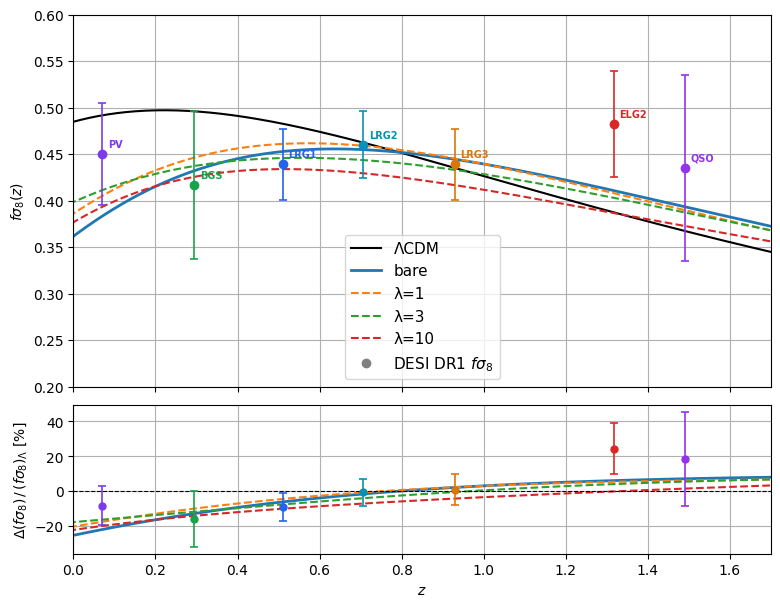

In [22]:
from matplotlib.lines import Line2D

fs8_lcdm_itp = interp1d(rl["z"], rl["fsigma8"], bounds_error=False, fill_value="extrapolate")

fig, (ax_f, ax_rat) = plt.subplots(
    2, 1, figsize=(9, 7),
    gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.07},
    sharex=True,
)

for name, rk in growth_results.items():
    c, ls, lw = COLORS_G[name], LS_MAP[name], LW_MAP[name]
    z_k = rk["z"]
    ax_f.plot(z_k, rk["fsigma8"], color=c, ls=ls, lw=lw, label=name)
    if name != "ΛCDM":
        dev = (rk["fsigma8"] - fs8_lcdm_itp(z_k)) / (np.abs(fs8_lcdm_itp(z_k)) + 1e-30) * 100
        ax_rat.plot(z_k, dev, color=c, ls=ls, lw=lw)

for (label, z_pt, fs8, err), col_pt in zip(DESI_POINTS, DESI_COLS):
    ax_f.errorbar(z_pt, fs8, yerr=err,
                  fmt="o", color=col_pt, capsize=3, capthick=1.2,
                  elinewidth=1.2, markersize=6, zorder=5)
    ax_f.annotate(label, xy=(z_pt, fs8), xytext=(4, 5),
                  textcoords="offset points", fontsize=7,
                  color=col_pt, fontweight="bold")

    fs8_ref      = fs8_lcdm_itp(z_pt)
    desi_dev     = (fs8 - fs8_ref) / (np.abs(fs8_ref) + 1e-30) * 100
    desi_dev_err = err              / (np.abs(fs8_ref) + 1e-30) * 100
    ax_rat.errorbar(z_pt, desi_dev, yerr=desi_dev_err,
                    fmt="o", color=col_pt, capsize=3, capthick=1.2,
                    elinewidth=1.2, markersize=5, zorder=5)

plt.setp(ax_f.get_xticklabels(), visible=False)
ax_f.set_ylabel(r"$f\sigma_8(z)$")
ax_f.set_xlim(0, 1.7)
ax_f.set_ylim(0.2, 0.6)
ax_f.grid(True)

desi_h = Line2D([0], [0], marker="o", color="gray", linestyle="None",
                markersize=6, label=r"DESI DR1 $f\sigma_8$")
handles = [l for l in ax_f.get_lines() if l.get_label() in COLORS_G] + [desi_h]
ax_f.legend(handles=handles, fontsize=11)

ax_rat.axhline(0, color="k", lw=0.8, ls="--")
ax_rat.set_xlabel(r"$z$")
ax_rat.set_ylabel(r"$\Delta(f\sigma_8)\,/\,(f\sigma_8)_\Lambda$ [%]")
ax_rat.grid(True)

plt.tight_layout()
plt.show()

## 7 — Rapport de vérification

In [ ]:
print("=== Modèle nu ===")
verify(s_bare)

for lam, sq in zip(LAMS, s_quints):
    print(f"\n=== Avec potentiel λ={lam} ===")
    verify(sq)


    print(" Omega_m(z=0) = ", float(sq.Omega_m(0.0)))

    sum_omega = sq.Omega_m(N) + sq.Omega_r(N) + sq.Omega_de_def(N)
    err = np.max(np.abs(sum_omega - 1.0))
    print(f"max|sum Ω_i - 1| = {err:.3e}")
    tol = 1e-10
    if np.all(np.abs(sum_omega - 1.0) < tol):
        print("Somme des densités égale à 1 pour tout N dans la précision numérique.")
    else:
        n_bad = np.sum(np.abs(sum_omega - 1.0) >= tol)
        print(f"{n_bad} points où la somme diffère de 1 au-delà de la tolérance de {tol}.")

## 8 — Test de cohérence : $\rho_\phi + p_\phi = Z \cdot \phi'^2 / a^2$

In [14]:
for lam, sq in zip(LAMS, s_quints):
    rho = sq.rho_phi(N)
    p   = sq.p_phi(N)
    Z   = sq.Z(N)
    pp  = sq.phi_prime(N)
    a   = np.exp(N)
    lhs = rho + p
    rhs = Z * pp**2 / a**2
    err = np.max(np.abs(lhs - rhs) / (np.abs(rhs) + 1e-30))
    print(f"λ={lam}: max|(ρ+p) - Z·φ'²/a²| / |rhs| = {err:.3e}  {'OK' if err < 1e-6 else 'FAIL'}")

λ=1: max|(ρ+p) - Z·φ'²/a²| / |rhs| = 1.753e-02  FAIL
λ=3: max|(ρ+p) - Z·φ'²/a²| / |rhs| = 6.098e+02  FAIL
λ=10: max|(ρ+p) - Z·φ'²/a²| / |rhs| = 2.020e-01  FAIL
